# XGBoost Classification for Cisplatin Drug Response

This notebook uses XGBoost with GPU acceleration to predict if cisplatin will be useful (effective) based on gene expression features.

**Classification threshold:** Median LC50 value
- LC50 < median → Useful (more sensitive, class 1)
- LC50 >= median → Not Useful (less sensitive, class 0)

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    r2_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Cisplatin Data

In [2]:
# Load cisplatin data
cisplatin_final = pd.read_parquet("data/processed/cisplatin_final.parquet")

print(f"Dataset shape: {cisplatin_final.shape}")
print(f"\nColumns: {cisplatin_final.columns.tolist()[:20]}...")
cisplatin_final.head()

Dataset shape: (742, 41148)

Columns: ['CELL_LINE_NAME', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1', 'A2ML1-AS2', 'A2MP1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AACSP1', 'AADAC', 'AADACL2', 'AADACL2-AS1', 'AADACL3']...


,CELL_LINE_NAME,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,...,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,ZZZ3,DRUG_NAME,LN_IC50
0,M14,3.9736,3.1408,0.0144,4.1326,0.4114,0.0000,0.0,0.0,0.0000,...,4.0488,2.6369,0.0976,3.7148,6.9590,0.0,4.3561,5.5622,Cisplatin,2.930082
1,MZ1-PC,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,Cisplatin,7.627100
2,HLE,0.0286,0.0566,0.0566,0.3219,1.3277,0.0286,0.0,0.0,0.0000,...,3.3001,3.0479,0.0000,4.3176,7.1488,0.0,3.4370,4.6502,Cisplatin,2.617914
3,SK-OV-3,5.1530,3.2824,0.0286,0.1110,0.4751,0.0976,0.0,0.0,0.0000,...,4.1018,2.6599,0.0000,3.2750,6.5308,NaN,3.1795,3.4777,Cisplatin,4.147191
4,SK-MEL-2,4.7887,3.4502,0.0000,5.5364,2.2172,0.0704,0.0,0.0,0.0704,...,4.2728,0.0144,1.9561,3.2913,6.2077,0.0,2.7845,4.8535,Cisplatin,5.400201


In [3]:
# Check for LC50 column
lc50_cols = [col for col in cisplatin_final.columns if 'LC50' in col.upper() or 'IC50' in col.upper()]
print(f"LC50/IC50 related columns: {lc50_cols}")

# Display basic stats
if lc50_cols:
    print(f"\nLC50 statistics:")
    print(cisplatin_final[lc50_cols].describe())

LC50/IC50 related columns: ['SLC50A1', 'LN_IC50']

LC50 statistics:
          SLC50A1     LN_IC50
count  742.000000  742.000000
mean     5.604487    3.192064
std      0.815469    1.845289
min      0.000000   -1.730244
25%      5.067250    1.807910
50%      5.603800    3.068794
75%      6.121975    4.425258
max      8.950000    9.229988


## 2. Create Binary Target Variable

In [4]:
# Define the LC50 column name (adjust if different)
LC50_COL = 'LN_IC50'  # Change this if your column has a different name

# Calculate median LC50
median_lc50 = cisplatin_final[LC50_COL].median()
print(f"Median {LC50_COL}: {median_lc50:.4f}")

# Create binary target: 1 = useful (below median), 0 = not useful (above median)
cisplatin_final['useful'] = (cisplatin_final[LC50_COL] < median_lc50).astype(int)

print(f"\nClass distribution:")
print(cisplatin_final['useful'].value_counts())
print(f"\nClass balance: {cisplatin_final['useful'].mean():.2%} useful")

Median LN_IC50: 3.0688

Class distribution:
useful
1    371
0    371
Name: count, dtype: int64

Class balance: 50.00% useful


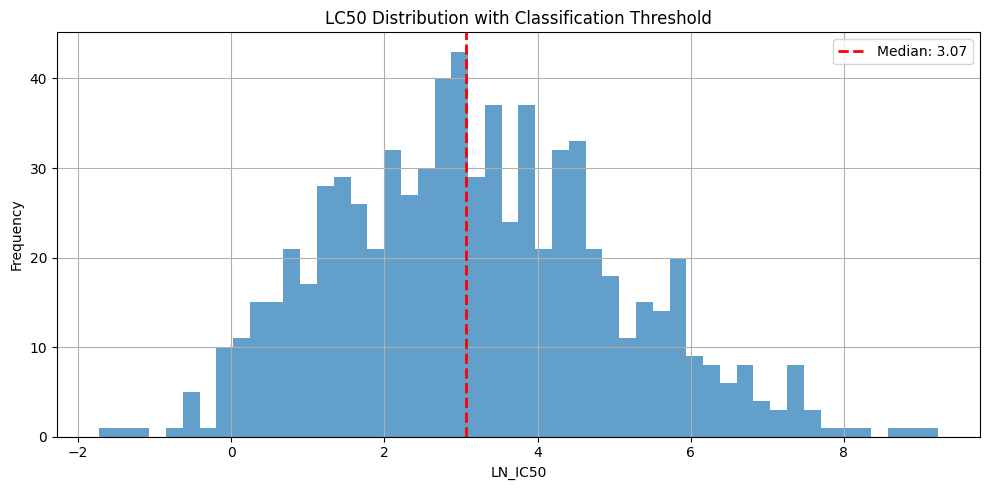

In [5]:
# Visualize LC50 distribution with threshold
fig, ax = plt.subplots(figsize=(10, 5))
cisplatin_final[LC50_COL].hist(bins=50, alpha=0.7, ax=ax)
ax.axvline(median_lc50, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lc50:.2f}')
ax.set_xlabel(LC50_COL)
ax.set_ylabel('Frequency')
ax.set_title('LC50 Distribution with Classification Threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Prepare Features and Target

In [6]:
# Identify metadata columns to exclude
metadata_cols = [
    'DRUG_NAME', 'DRUG_ID', 'IC50', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE',
    'CELL_LINE_NAME', 'CELL_LINE_ID', 'COSMIC_ID', 'SANGER_ID', 'SAMPLE_ID',
    'TCGA_DESC', 'TISSUE', 'TISSUE_TYPE', 'CANCER_TYPE', 'CANCER_TYPE_DETAIL',
    'MODEL_ID', 'MODEL_NAME', 'DATASET', 'SOURCE', 'INDEX', 'useful', 'LC50'
]

# Get feature columns (everything except metadata)
feature_cols = [col for col in cisplatin_final.columns if col not in metadata_cols]
print(f"Number of features: {len(feature_cols)}")
print(f"Feature columns (first 10): {feature_cols[:10]}")

Number of features: 41145
Feature columns (first 10): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1', 'A2ML1-AS2', 'A2MP1', 'A3GALT2']


In [7]:
# Prepare X and y
X = cisplatin_final[feature_cols].copy()
y = cisplatin_final['useful'].copy()

# Convert to float32 for GPU efficiency
X = X.astype(np.float32)

# Handle any missing values
if X.isna().any().any():
    print(f"Missing values found, filling with 0...")
    X = X.fillna(0)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Missing values found, filling with 0...
Features shape: (742, 41145)
Target shape: (742,)


## 4. Train/Test Split

In [8]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())

Training set: 593 samples
Test set: 149 samples

Training class distribution:
useful
1    297
0    296
Name: count, dtype: int64


## 5. Train XGBoost with GPU

In [9]:
# Initialize XGBoost classifier with GPU
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='logloss'
)

print("Training XGBoost on GPU...")
model.fit(X_train, y_train)
print("Training complete!")

Training XGBoost on GPU...
Training complete!


## 6. Predictions and Evaluation

In [10]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"R² Score:  {r2:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("=" * 50)

MODEL PERFORMANCE
Accuracy:  0.7651
R² Score:  0.2377
ROC-AUC:   0.8092


In [11]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Useful', 'Useful']))


Classification Report:
              precision    recall  f1-score   support

  Not Useful       0.76      0.77      0.77        75
      Useful       0.77      0.76      0.76        74

    accuracy                           0.77       149
   macro avg       0.77      0.77      0.77       149
weighted avg       0.77      0.77      0.77       149



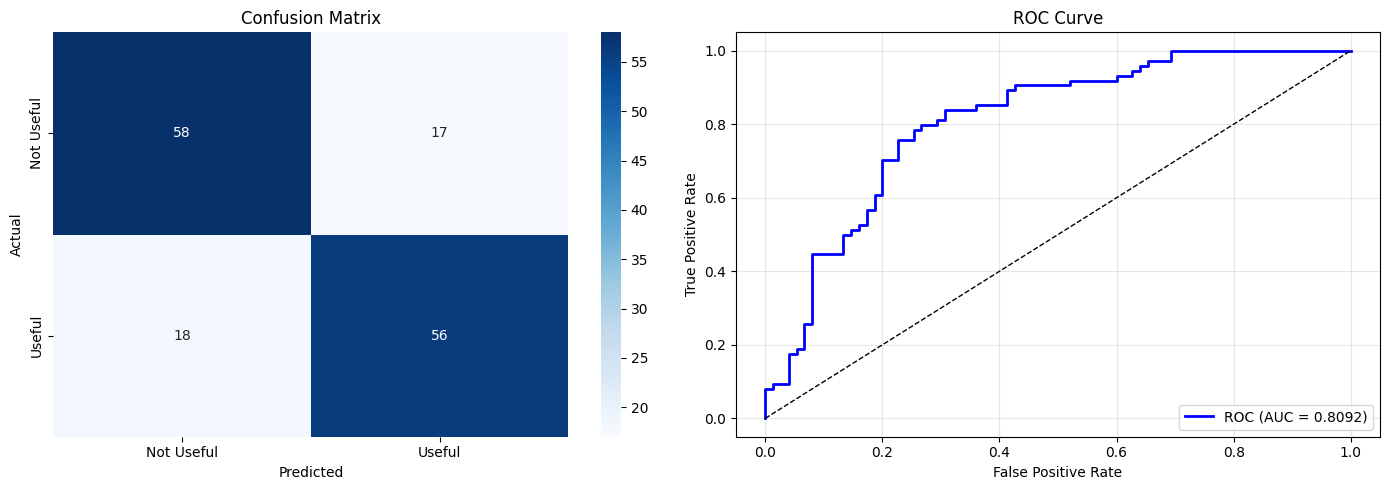

In [12]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Useful', 'Useful'],
            yticklabels=['Not Useful', 'Useful'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Importance

In [13]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

Top 20 Most Important Features:
  feature  importance
  SEPTIN6    0.032570
     PPIC    0.020429
    PCDH1    0.013347
 ADAMTS15    0.008547
  ARHGAP9    0.008367
    TAF4B    0.007663
   CRYBG2    0.007604
     GJB1    0.007590
   KDELR3    0.007007
    ABHD5    0.007004
  SELENOK    0.006969
   N6AMT1    0.006836
   RAB5IF    0.006792
LINC01679    0.006786
     CDK8    0.005877
     LMO4    0.005727
     RLN2    0.005708
    CXCR2    0.005609
 RPS3AP40    0.005602
    PANX1    0.005564


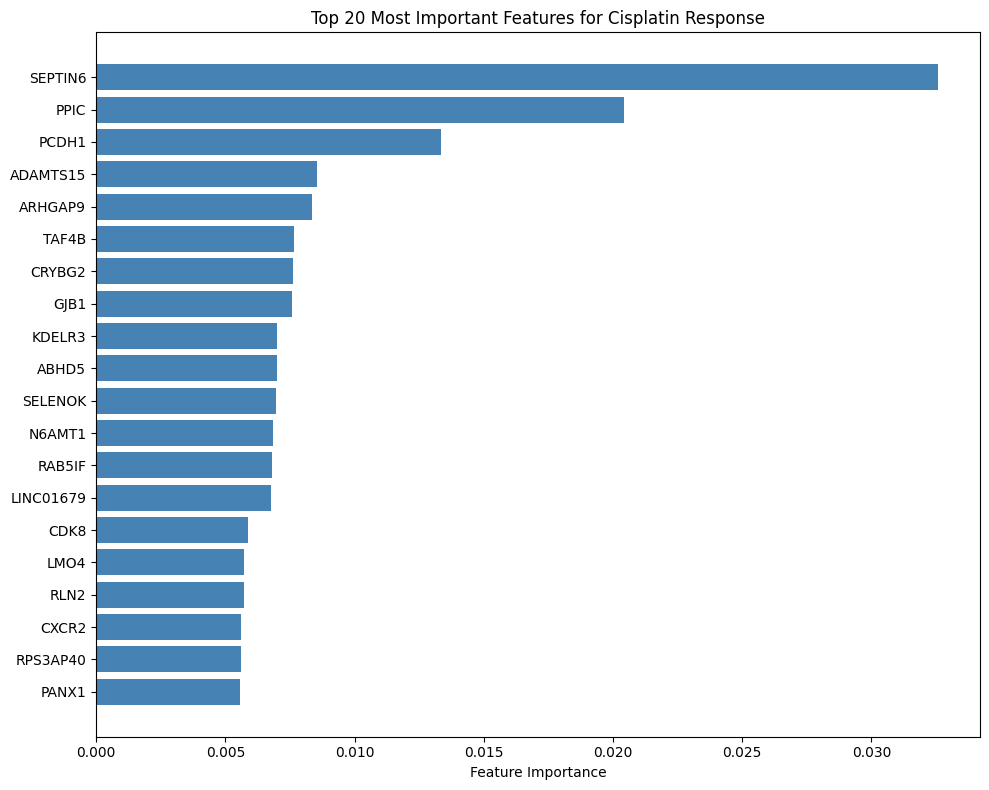

In [14]:
# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
ax.barh(range(len(top_20)), top_20['importance'].values, color='steelblue')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Most Important Features for Cisplatin Response')
plt.tight_layout()
plt.show()

## 8. Summary

In [ ]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Dataset: cisplatin_final.parquet")
print(f"Total samples: {len(cisplatin_final)}")
print(f"Features: {len(feature_cols)}")
print(f"Classification threshold: Median {LC50_COL} = {median_lc50:.4f}")
print(f"\nModel: XGBoost (GPU accelerated)")
print(f"  - n_estimators: 100")
print(f"  - max_depth: 6")
print(f"  - learning_rate: 0.1")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - R² Score:  {r2:.4f}")
print(f"  - ROC-AUC:   {roc_auc:.4f}")
print("=" * 60)

In [18]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, r2_score
import numpy as np
from tqdm import tqdm

N_TRIALS = 20

# Custom progress bar
pbar = tqdm(total=N_TRIALS, desc="Optuna Tuning")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': 42,
        'eval_metric': 'logloss',
        'early_stopping_rounds': 10
    }
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []
    r2_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        
        y_proba = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, y_proba))
        r2_scores.append(r2_score(y_val, y_proba))
        
        trial.report(np.mean(auc_scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    mean_auc = np.mean(auc_scores)
    mean_r2 = np.mean(r2_scores)
    
    # Store R² in trial for later access
    trial.set_user_attr('r2_score', mean_r2)
    
    # Print trial results
    print(f"Trial {trial.number:2d} | AUC: {mean_auc:.4f} | R²: {mean_r2:.4f} | "
          f"n_est: {params['n_estimators']:3d} | depth: {params['max_depth']} | "
          f"lr: {params['learning_rate']:.4f}")
    
    # Update progress bar (FIXED: handle first trial)
    pbar.update(1)
    try:
        completed = [t for t in trial.study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if len(completed) > 0:
            best_auc = max(t.value for t in completed)
            pbar.set_postfix({'best_auc': f"{best_auc:.4f}"})
    except:
        pass
    
    return mean_auc

# Run optimization
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction='maximize', 
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

print("=" * 80)
print("HYPERPARAMETER OPTIMIZATION")
print("=" * 80)
study.optimize(objective, n_trials=N_TRIALS)
pbar.close()

# Best trial info
best_trial = study.best_trial
print("\n" + "=" * 80)
print("BEST TRIAL")
print("=" * 80)
print(f"Trial #:   {best_trial.number}")
print(f"ROC-AUC:   {best_trial.value:.4f}")
print(f"R² Score:  {best_trial.user_attrs['r2_score']:.4f}")
print(f"\nBest Parameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

# Train best model
print("\n" + "=" * 80)
print("FINAL MODEL EVALUATION")
print("=" * 80)
best_params = {k: v for k, v in study.best_params.items() if k != 'early_stopping_rounds'}
best_model = XGBClassifier(
    **best_params,
    tree_method='hist',
    device='cuda',
    random_state=42
)
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"R² Score:  {r2_score(y_test, y_pred_proba_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print("=" * 80)


Optuna Tuning:   5%|▌         | 1/20 [01:27<27:42, 87.48s/it]


HYPERPARAMETER OPTIMIZATION


Trial  0 | AUC: 0.7739 | R²: 0.2266 | n_est: 106 | depth: 8 | lr: 0.1856


Trial  1 | AUC: 0.8036 | R²: 0.2757 | n_est:  58 | depth: 8 | lr: 0.1468


Trial  2 | AUC: 0.8105 | R²: 0.2928 | n_est: 175 | depth: 4 | lr: 0.0693


...

Trial 12 | AUC: 0.8126 | R²: 0.2962 | n_est: 182 | depth: 5 | lr: 0.0865


Trial 15 | AUC: 0.8145 | R²: 0.2871 | n_est: 200 | depth: 5 | lr: 0.1183


Trial 16 | AUC: 0.8116 | R²: 0.2838 | n_est:  78 | depth: 7 | lr: 0.1176


Optuna Tuning:  55%|█████▌    | 11/20 [12:03<09:52, 65.82s/it, best_auc=0.8157]



BEST TRIAL
Trial #:   7
ROC-AUC:   0.8157
R² Score:  0.2991

Best Parameters:
  n_estimators: 55
  max_depth: 8
  learning_rate: 0.07949502872202294
  subsample: 0.8987566853061946
  colsample_bytree: 0.7935133228268233
  min_child_weight: 4

FINAL MODEL EVALUATION
Accuracy:  0.7181
R² Score:  0.2394
ROC-AUC:   0.7964


In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, r2_score, roc_auc_score
from tqdm import tqdm

# Define different hyperparameter configurations to try
configs = [
    {
        'name': 'Baseline',
        'params': {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
    },
    {
        'name': 'Deeper Trees',
        'params': {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
    },
    {
        'name': 'More Trees + Low LR',
        'params': {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.9}
    },
    {
        'name': 'Shallow + Regularized',
        'params': {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'reg_alpha': 1.0, 'reg_lambda': 5.0}
    },
    {
        'name': 'Balanced',
        'params': {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.08, 'subsample': 0.85, 'colsample_bytree': 0.85}
    },
    {
        'name': 'High Trees + Medium Depth',
        'params': {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8}
    },
    {
        'name': 'Aggressive Regularization',
        'params': {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'reg_alpha': 0.5, 'reg_lambda': 3.0, 'gamma': 0.2}
    },
    {
        'name': 'Wide + Shallow',
        'params': {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.15, 'colsample_bytree': 0.7}
    },
]

# Run trials
results = []
print("=" * 80)
print("HYPERPARAMETER TRIALS")
print("=" * 80)

for config in tqdm(configs, desc="Running trials"):
    model = XGBClassifier(
        **config['params'],
        tree_method='hist',
        device='cuda',
        random_state=42,
        eval_metric='logloss'
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    r2 = r2_score(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'name': config['name'],
        'accuracy': acc,
        'r2': r2,
        'auc': auc,
        'params': config['params']
    })
    
    print(f"\n{config['name']:25s} | Acc: {acc:.4f} | R²: {r2:.4f} | AUC: {auc:.4f}")

# Summary table
print("\n" + "=" * 80)
print("RESULTS SUMMARY (sorted by R²)")
print("=" * 80)
results_df = pd.DataFrame(results).sort_values('r2', ascending=False)
print(results_df[['name', 'accuracy', 'r2', 'auc']].to_string(index=False))

# Best config
best = results_df.iloc[0]
print("\n" + "=" * 80)
print(f"BEST CONFIG: {best['name']}")
print("=" * 80)
print(f"Accuracy: {best['accuracy']:.4f}")
print(f"R²:       {best['r2']:.4f}")
print(f"AUC:      {best['auc']:.4f}")
print(f"\nParameters: {best['params']}")

HYPERPARAMETER TRIALS



Baseline                  | Acc: 0.7651 | R²: 0.2377 | AUC: 0.8092



Deeper Trees              | Acc: 0.7383 | R²: 0.2344 | AUC: 0.8083



More Trees + Low LR       | Acc: 0.7651 | R²: 0.2784 | AUC: 0.8168



Shallow + Regularized     | Acc: 0.7517 | R²: 0.2621 | AUC: 0.8187



Balanced                  | Acc: 0.7785 | R²: 0.2863 | AUC: 0.8263



High Trees + Medium Depth | Acc: 0.7584 | R²: 0.2747 | AUC: 0.8171



Aggressive Regularization | Acc: 0.7450 | R²: 0.2498 | AUC: 0.8088


Running trials: 100%|██████████| 8/8 [10:16<00:00, 77.07s/it]


Wide + Shallow            | Acc: 0.7450 | R²: 0.2266 | AUC: 0.8119

RESULTS SUMMARY (sorted by R²)
                     name  accuracy       r2      auc
                 Balanced  0.778523 0.286259 0.826306
      More Trees + Low LR  0.765101 0.278419 0.816757
High Trees + Medium Depth  0.758389 0.274698 0.817117
    Shallow + Regularized  0.751678 0.262111 0.818739
Aggressive Regularization  0.744966 0.249775 0.808829
                 Baseline  0.765101 0.237662 0.809189
             Deeper Trees  0.738255 0.234424 0.808288
           Wide + Shallow  0.744966 0.226559 0.811892

BEST CONFIG: Balanced
Accuracy: 0.7785
R²:       0.2863
AUC:      0.8263

Parameters: {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.08, 'subsample': 0.85, 'colsample_bytree': 0.85}
